# SkillSync ML Models — Full Training Notebook

## Overview

Complete ML pipeline for the SkillSync HRMS.  
Run cells **top to bottom** in Google Colab after uploading  to .

| Model | Task | Algorithm | Key Fix |
|-------|------|-----------|--------|
| **1 — Turnover Prediction** | Binary classification | 7 classifiers + Optuna tuning | SMOTE inside  — no CV leakage |
| **2 — Role Fit Scoring** | Regression | GradientBoostingRegressor + Optuna | Removed  target leakage (R² ~0.92) |
| **3 — Skill Gap Analysis** | Aggregation | Rule-based |  metric; 5 criticality tiers |
| **4 — Learning Path** | Regression | LightGBM + Knowledge Graph DAG | LOO mean for  — eliminates target leakage |

## Setup
1. Upload the entire  folder to Google Drive under 
2. Run **Cell 1** to mount Drive, **Cell 2** to verify files, **Cell 3** to install packages
3. Outputs are saved to 


In [28]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [29]:
# CELL 2: Set your Data directory
DATA_DIR = '/content/drive/MyDrive/Data'
import os
print('Files found:', sorted(os.listdir(DATA_DIR)))

Files found: ['attendance.csv', 'attendance_summary.csv', 'departments.csv', 'employee_skill_matrix.csv', 'employees_core.csv', 'evaluations.csv', 'generate_skillsync_final.py', 'job_role_requirements.csv', 'job_roles.csv', 'learning_resources.csv', 'leave_requests.csv', 'mobility_history.csv', 'monthly_payroll.csv', 'replacement_ml_dataset.csv', 'skill_chain_dag.csv', 'skill_gap_dataset.csv', 'skills_catalog.csv', 'training_history.csv', 'training_skill_map.csv', 'turnover_ml_dataset.csv']


In [30]:
# CELL 3: Install dependencies
!pip install -q lightgbm xgboost optuna shap imbalanced-learn networkx scikit-learn pandas matplotlib seaborn

In [31]:
# CELL 4: Common imports & helpers
import warnings
warnings.filterwarnings('ignore')
import os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)

OUTPUT_DIR = '/content/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_csv(filename):
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df.columns = df.columns.str.replace(r'^\ufeff', '', regex=True).str.strip()
    return df

def get_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    raise KeyError(f'None of {candidates} found. Available: {df.columns.tolist()}')

print('Setup complete. Output:', OUTPUT_DIR)

Setup complete. Output: /content/models


---
# Model 1: Employee Turnover Prediction (FIXED)

## Bugs fixed
1. **SMOTE leakage** — SMOTE was previously applied to the full training set *before* cross-validation, meaning synthetic samples from the training folds leaked into validation folds, giving an artificially inflated CV AUC of ~0.94 against a real test AUC of 0.75. Fix: SMOTE is now wrapped inside an `imblearn.Pipeline` and only applied within each fold's training split.
2. **Undertuned XGBoost & LightGBM** — Both previously scored below Logistic Regression. GridSearchCV was used for Random Forest but not these models. Fix: All top 4 classifiers are now tuned with Optuna (50 trials each).
3. **CV on SMOTE-resampled data** — The old CV evaluated on the same resampled pool that SMOTE generated from. Fix: CV now uses the raw (pre-SMOTE) training data inside the pipeline, with SMOTE applied per fold.

In [ ]:
print('=' * 70)
print('MODEL 1: EMPLOYEE TURNOVER PREDICTION')
print('=' * 70)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

df1 = load_csv('turnover_ml_dataset.csv')
print(f'Shape: {df1.shape}  |  Turnover rate: {df1["turnover_label"].mean()*100:.2f}%')
display(df1.describe())

In [ ]:
# Visualize class imbalance & key driver
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df1['turnover_label'].value_counts()
axes[0].bar(['No Turnover', 'Turnover'], counts.values, color=['steelblue','salmon'])
for i,v in enumerate(counts.values): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (before SMOTE)', fontweight='bold')
df1.groupby(pd.qcut(df1['absence_rate'],5,duplicates='drop'))['turnover_label'].mean().plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Turnover Rate by Absence Rate Quintile', fontweight='bold')
axes[1].set_ylabel('Turnover Rate'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

In [ ]:
# Preprocessing — identical to original
df1c = df1.copy()
if 'avg_feedback_score' in df1c.columns:
    df1c['avg_feedback_score'] = df1c['avg_feedback_score'].fillna(df1c['avg_feedback_score'].median())
for col in df1c.select_dtypes(include=[np.number]).columns:
    if col != 'employee_id': df1c[col] = df1c[col].fillna(df1c[col].median())
for col in df1c.select_dtypes(include=[np.number]).columns:
    if col == 'employee_id': continue
    n_inf = int(np.isinf(df1c[col]).sum())
    if n_inf > 0: df1c[col] = df1c[col].replace([np.inf,-np.inf], np.nan).fillna(df1c[col].median())
df1c = df1c.drop_duplicates(subset=['employee_id'], keep='first')

def cap(df, col, lo=0.01, hi=0.99):
    l,u = df[col].quantile(lo), df[col].quantile(hi)
    df[col] = df[col].clip(l, u)
for col in ['salary_egp','total_overtime_hours','total_early_leave_min',
             'commute_distance_km','absence_rate','late_rate']:
    if col in df1c.columns: cap(df1c, col)

# Feature engineering
df1c['tenure_vs_experience']  = df1c['tenure_years'] / (df1c['total_working_years'] + 1e-5)
df1c['promotion_gap_ratio']   = df1c['years_since_last_promotion'] / (df1c['tenure_years'] + 1e-5)
df1c['salary_per_year_exp']   = df1c['salary_egp'] / (df1c['total_working_years'] + 1e-5)
df1c['overtime_intensity']    = df1c['total_overtime_hours'] / (df1c['avg_worked_hours'] + 1e-5)
df1c['absence_severity']      = df1c['absence_rate'] * df1c['late_rate']
df1c['attendance_quality']    = df1c['attendance_score'] * df1c['avg_worked_hours']
df1c['performance_score']     = (df1c['latest_eval_score'] + df1c['kpi_score']) / 2
df1c['engagement_score']      = (df1c['courses_completed']*10 + df1c['avg_training_score']) / (df1c['avg_feedback_score']+1)
df1c['work_balance_fit']      = df1c['work_life_balance'] * df1c['role_fit_score']

for col in [c for c in df1c.select_dtypes(include=['object']).columns if c != 'employee_id']:
    df1c[col] = LabelEncoder().fit_transform(df1c[col].astype(str))

feature_cols1 = [c for c in df1c.columns if c not in ['employee_id','turnover_label']]
X1 = df1c[feature_cols1].values   # numpy array for sklearn Pipeline
y1 = df1c['turnover_label'].values
print(f'Features: {len(feature_cols1)}  |  Samples: {len(X1)}')

# ── FIX: train/test split on RAW data — NO SMOTE yet ─────────────────────────
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)

scaler1 = StandardScaler()
X1_tr_s = scaler1.fit_transform(X1_tr)
X1_te_s = scaler1.transform(X1_te)
print(f'Train: {len(X1_tr)}  Test: {len(X1_te)}')
print('NOTE: SMOTE is now applied inside the Pipeline — no pre-resampling done here.')

In [ ]:
# ── FIX: Build SMOTE-inside-Pipeline for all 7 classifiers ───────────────────
# imblearn.Pipeline runs SMOTE only on the training fold during CV,
# so validation folds never see synthetic samples.

def make_pipe(clf):
    """Wraps a classifier in an imblearn Pipeline with SMOTE."""
    return ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   clf)
    ])

base_clfs = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost':             XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss'),
    'LightGBM':            LGBMClassifier(random_state=42, n_estimators=100, verbose=-1),
    'AdaBoost':            AdaBoostClassifier(random_state=42, n_estimators=100),
}

# Train on scaled training set (SMOTE fires inside the pipeline during fit)
results1 = []; trained1 = {}
cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in base_clfs.items():
    pipe = make_pipe(clf)
    print(f'Training {name}...', end=' ')
    pipe.fit(X1_tr_s, y1_tr)                        # SMOTE only on X1_tr_s
    y_pred  = pipe.predict(X1_te_s)
    y_proba = pipe.predict_proba(X1_te_s)[:,1]

    # ── FIX: CV on raw (pre-SMOTE) data — pipeline applies SMOTE per fold ────
    cv_f1  = cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1, scoring='f1', n_jobs=-1)
    cv_auc = cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1, scoring='roc_auc', n_jobs=-1)

    results1.append({
        'Model':    name,
        'Accuracy': accuracy_score(y1_te, y_pred),
        'Precision':precision_score(y1_te, y_pred, zero_division=0),
        'Recall':   recall_score(y1_te, y_pred),
        'F1-Score': f1_score(y1_te, y_pred),
        'ROC-AUC':  roc_auc_score(y1_te, y_proba),
        'CV F1':    cv_f1.mean(),
        'CV AUC':   cv_auc.mean(),
    })
    trained1[name] = {'pipe': pipe, 'preds': y_pred, 'probas': y_proba}
    print(f'F1={results1[-1]["F1-Score"]:.4f}  AUC={results1[-1]["ROC-AUC"]:.4f}  '
          f'CV_F1={cv_f1.mean():.4f}±{cv_f1.std():.4f}  CV_AUC={cv_auc.mean():.4f}±{cv_auc.std():.4f}')

res1_df = pd.DataFrame(results1).sort_values('F1-Score', ascending=False)
print('\n--- SUMMARY (test set) ---')
display(res1_df.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV F1','CV AUC'],
    color='lightgreen'))

print('\nNOTE: CV F1 and CV AUC are now computed with SMOTE inside each fold.')
print('The gap between CV and test metrics should be much smaller than before.')

In [ ]:
# Metric comparison bar chart
metrics1 = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(res1_df)); w = 0.15
fig, ax = plt.subplots(figsize=(16,6))
for i,m in enumerate(metrics1):
    ax.bar(x+i*w, res1_df[m], w, label=m)
ax.set_xticks(x+w*2); ax.set_xticklabels(res1_df['Model'], rotation=20, ha='right')
ax.set_ylim(0.4,1.05); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
ax.set_title('Model 1 — All Classifiers: Test Metrics', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

# CV vs test AUC gap comparison
fig, ax2 = plt.subplots(figsize=(12,5))
xp = np.arange(len(res1_df))
ax2.bar(xp - 0.2, res1_df['CV AUC'], 0.35, label='CV AUC ', color='steelblue')
ax2.bar(xp + 0.2, res1_df['ROC-AUC'], 0.35, label='Test AUC', color='coral')
ax2.set_xticks(xp); ax2.set_xticklabels(res1_df['Model'], rotation=20, ha='right')
ax2.set_ylim(0.4, 1.05); ax2.legend(); ax2.grid(axis='y', alpha=0.3)
ax2.set_title('CV AUC vs Test AUC — gap should now be small (SMOTE inside pipeline)', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Best model deep-dive
best1_name  = res1_df.iloc[0]['Model']
best1_pipe  = trained1[best1_name]['pipe']
best1_preds = trained1[best1_name]['preds']
best1_probas= trained1[best1_name]['probas']

print(f'Best Model (by test F1): {best1_name}')

fig, axes = plt.subplots(1,2,figsize=(14,6))
cm1 = confusion_matrix(y1_te, best1_preds)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Turnover','Turnover'], yticklabels=['No Turnover','Turnover'])
axes[0].set(title=f'Confusion Matrix — {best1_name} ', xlabel='Predicted', ylabel='Actual')
fpr1, tpr1, _ = roc_curve(y1_te, best1_probas)
auc1 = roc_auc_score(y1_te, best1_probas)
axes[1].plot(fpr1, tpr1, color='darkorange', lw=2, label=f'AUC={auc1:.4f}')
axes[1].plot([0,1],[0,1],'navy',lw=2,linestyle='--',label='Random')
axes[1].set(xlim=[0,1],ylim=[0,1.05],xlabel='FPR',ylabel='TPR',
            title=f'ROC Curve — {best1_name} ')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(classification_report(y1_te, best1_preds, target_names=['No Turnover','Turnover']))

In [ ]:
# Feature importance from best model (if available)
best1_clf = best1_pipe.named_steps['clf']
if hasattr(best1_clf, 'feature_importances_'):
    imps1 = best1_clf.feature_importances_
    idx1  = np.argsort(imps1)[::-1][:20]
    plt.figure(figsize=(12,8))
    plt.barh(range(len(idx1)), imps1[idx1], color='steelblue')
    plt.yticks(range(len(idx1)), [feature_cols1[i] for i in idx1])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features — {best1_name}', fontweight='bold')
    plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
elif hasattr(best1_clf, 'coef_'):
    coef1 = np.abs(best1_clf.coef_[0])
    idx1  = np.argsort(coef1)[::-1][:20]
    plt.figure(figsize=(12,8))
    plt.barh(range(len(idx1)), coef1[idx1], color='steelblue')
    plt.yticks(range(len(idx1)), [feature_cols1[i] for i in idx1])
    plt.xlabel('|Coefficient|')
    plt.title(f'Top 20 Feature Coefficients — {best1_name}', fontweight='bold')
    plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

In [ ]:
# ── FIX: Optuna tuning for top 4 classifiers (replaces GridSearchCV) ─────────
# Optuna with 50 trials per model is far more thorough than GridSearchCV.
# Each Optuna objective uses the SMOTE-inside-Pipeline for honest CV.

from imblearn.pipeline import Pipeline as ImbPipeline

def make_optuna_pipe(clf):
    return ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', clf)])

def tune_model(name, objective_fn, n_trials=50):
    print(f'\nOptuna tuning: {name} ({n_trials} trials)...')
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=n_trials, show_progress_bar=False)
    print(f'  Best CV F1: {study.best_value:.4f}')
    print(f'  Best params: {study.best_params}')
    return study

cv1_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
def rf_objective(trial):
    clf = RandomForestClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500),
        max_depth        = trial.suggest_int('max_depth', 5, 30),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features     = trial.suggest_categorical('max_features', ['sqrt','log2']),
        random_state=42, n_jobs=-1)
    pipe = make_optuna_pipe(clf)
    return cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1_opt, scoring='f1', n_jobs=-1).mean()

study_rf = tune_model('Random Forest', rf_objective)

# --- XGBoost ---
def xgb_objective(trial):
    clf = XGBClassifier(
        n_estimators  = trial.suggest_int('n_estimators', 100, 500),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth     = trial.suggest_int('max_depth', 3, 10),
        subsample     = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha     = trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        reg_lambda    = trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        eval_metric='logloss', random_state=42)
    pipe = make_optuna_pipe(clf)
    return cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1_opt, scoring='f1', n_jobs=-1).mean()

study_xgb = tune_model('XGBoost', xgb_objective)

# --- LightGBM ---
def lgbm_objective(trial):
    clf = LGBMClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 15, 127),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 50),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        random_state=42, verbose=-1)
    pipe = make_optuna_pipe(clf)
    return cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1_opt, scoring='f1', n_jobs=-1).mean()

study_lgbm = tune_model('LightGBM', lgbm_objective)

# --- Gradient Boosting ---
def gb_objective(trial):
    clf = GradientBoostingClassifier(
        n_estimators  = trial.suggest_int('n_estimators', 100, 400),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth     = trial.suggest_int('max_depth', 2, 8),
        subsample     = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        random_state=42)
    pipe = make_optuna_pipe(clf)
    return cross_val_score(pipe, X1_tr_s, y1_tr, cv=cv1_opt, scoring='f1', n_jobs=-1).mean()

study_gb = tune_model('Gradient Boosting', gb_objective)

In [ ]:
# Build, train & evaluate all tuned models on the held-out test set
tuned_models = {
    'Random Forest (Optuna)':     RandomForestClassifier(**study_rf.best_params,   random_state=42, n_jobs=-1),
    'XGBoost (Optuna)':           XGBClassifier(**study_xgb.best_params,           eval_metric='logloss', random_state=42),
    'LightGBM (Optuna)':          LGBMClassifier(**study_lgbm.best_params,         random_state=42, verbose=-1),
    'Gradient Boosting (Optuna)': GradientBoostingClassifier(**study_gb.best_params, random_state=42),
}

tuned_results = []; tuned_trained = {}
for name, clf in tuned_models.items():
    pipe = make_optuna_pipe(clf)
    pipe.fit(X1_tr_s, y1_tr)
    y_pred  = pipe.predict(X1_te_s)
    y_proba = pipe.predict_proba(X1_te_s)[:,1]
    tuned_results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y1_te, y_pred),
        'Precision':precision_score(y1_te, y_pred, zero_division=0),
        'Recall':   recall_score(y1_te, y_pred),
        'F1-Score': f1_score(y1_te, y_pred),
        'ROC-AUC':  roc_auc_score(y1_te, y_proba),
    })
    tuned_trained[name] = {'pipe': pipe, 'preds': y_pred, 'probas': y_proba}
    print(f'{name}: F1={tuned_results[-1]["F1-Score"]:.4f}  AUC={tuned_results[-1]["ROC-AUC"]:.4f}')

tuned_df = pd.DataFrame(tuned_results).sort_values('F1-Score', ascending=False)
print('\n--- TUNED MODELS (test set) ---')
display(tuned_df.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'], color='lightgreen'))

In [ ]:
# Select overall best model across both baseline and tuned sets
all_results = pd.concat([res1_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']],
                          tuned_df], ignore_index=True).sort_values('F1-Score', ascending=False)

print('=== FINAL RANKING — all models ===')
display(all_results.reset_index(drop=True))

best1_final_name  = all_results.iloc[0]['Model']
all_trained = {**trained1, **tuned_trained}
best1_final_pipe  = all_trained[best1_final_name]['pipe']
best1_final_preds = all_trained[best1_final_name]['preds']
best1_final_proba = all_trained[best1_final_name]['probas']

print(f'\nOverall Best: {best1_final_name}')
print(classification_report(y1_te, best1_final_preds, target_names=['No Turnover','Turnover']))

fig, axes = plt.subplots(1,2,figsize=(14,6))
cm_final = confusion_matrix(y1_te, best1_final_preds)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Turnover','Turnover'], yticklabels=['No Turnover','Turnover'])
axes[0].set(title=f'Confusion Matrix — {best1_final_name}', xlabel='Predicted', ylabel='Actual')
fpr_f, tpr_f, _ = roc_curve(y1_te, best1_final_proba)
axes[1].plot(fpr_f, tpr_f, color='darkorange', lw=2, label=f'AUC={all_results.iloc[0]["ROC-AUC"]:.4f}')
axes[1].plot([0,1],[0,1],'navy',lw=2,linestyle='--',label='Random')
axes[1].set(xlim=[0,1],ylim=[0,1.05],xlabel='FPR',ylabel='TPR',
            title=f'ROC — {best1_final_name}')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

joblib.dump(best1_final_pipe,  f'{OUTPUT_DIR}/best_turnover_model.pkl')
joblib.dump(scaler1,           f'{OUTPUT_DIR}/scaler.pkl')
joblib.dump(feature_cols1,     f'{OUTPUT_DIR}/turnover_features.pkl')
print(f'Model 1 saved.')

---
# Model 2: Role Fit Scoring
**Fix applied**: `weighted_gap` was removed (it is algebraically identical to `readiness_score` — pure leakage giving fake R²=1.0).  
Replaced with `emp_avg_proficiency` + `role_avg_requirement` for honest R² ~0.92.

In [13]:
print('=' * 70)
print('MODEL 2: ROLE FIT SCORING  (leakage-free)')
print('=' * 70)

import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
optuna.logging.set_verbosity(optuna.logging.WARNING)

emp2 = load_csv('employee_skill_matrix.csv')
req2 = load_csv('job_role_requirements.csv')

emp2_id  = get_col(emp2, ['employee_id', 'Employee_id'])
emp2_sk  = get_col(emp2, ['skill_id',    'Skill_id'])
emp2_pr  = get_col(emp2, ['proficiency', 'Proficiency'])
req_role = get_col(req2, ['job_role_id',      'Job_role_id'])
req_sk   = get_col(req2, ['required_skill_id','skill_id','Required_skill_id'])
req_min  = get_col(req2, ['min_proficiency',  'Min_proficiency'])
req_wt   = get_col(req2, ['importance_weight','Importance_weight'])

print(f'Employees: {emp2[emp2_id].nunique()}  |  Roles: {req2[req_role].nunique()}')
print(f'Employee proficiency range: {emp2[emp2_pr].min()}–{emp2[emp2_pr].max()}  mean={emp2[emp2_pr].mean():.2f}')
print(f'Role requirement range:     {req2[req_min].min()}–{req2[req_min].max()}  mean={req2[req_min].mean():.2f}')

MODEL 2: ROLE FIT SCORING  (leakage-free)
Employees: 200  |  Roles: 22
Employee proficiency range: 1–4  mean=1.17
Role requirement range:     1–4  mean=2.63


In [14]:
# Precompute per-employee avg proficiency & per-role avg requirement
emp_avg_prof2 = emp2.groupby(emp2_id)[emp2_pr].mean().to_dict()
role_avg_req2 = req2.groupby(req_role)[req_min].mean().to_dict()

print('Building (employee × role) feature matrix...')
records2 = []
for emp_id in emp2[emp2_id].unique():
    emp_rows = emp2[emp2[emp2_id] == emp_id]
    emp_dict = dict(zip(emp_rows[emp2_sk], emp_rows[emp2_pr]))
    for role_id in req2[req_role].unique():
        req_rows = req2[req2[req_role] == role_id]
        if req_rows.empty: continue
        n_req = len(req_rows)
        n_match = n_miss = wg = ws = mg = 0; mp = []
        for _, r in req_rows.iterrows():
            cur = float(emp_dict.get(r[req_sk], 0.0))
            gap = max(float(r[req_min]) - cur, 0.0)
            wg += gap * float(r[req_wt])
            ws += 4  * float(r[req_wt])
            mg  = max(mg, gap)
            if gap == 0: n_match += 1; mp.append(cur)
            else: n_miss += 1
        readiness = 1.0 - (wg / ws) if ws > 0 else 1.0
        records2.append({
            'n_required':        n_req,
            'n_matching':        n_match,
            'n_missing':         n_miss,
            'coverage_ratio':    n_match / n_req if n_req else 0.0,
            'max_gap':           mg,
            'avg_matched_prof':  float(np.mean(mp)) if mp else 0.0,
            # Two new informative features — no leakage
            'emp_avg_proficiency': emp_avg_prof2.get(emp_id, 1.0),
            'role_avg_requirement': role_avg_req2.get(role_id, 2.0),
            'readiness_score':   readiness,
        })

df2 = pd.DataFrame(records2)
print(f'Feature matrix: {df2.shape}')
print(f'\nReadiness score distribution:')
display(df2['readiness_score'].describe().to_frame().T)

Building (employee × role) feature matrix...
Feature matrix: (4400, 9)

Readiness score distribution:


,count,mean,std,min,25%,50%,75%,max
readiness_score,4400.0,0.436,0.186182,0.0875,0.2875,0.4375,0.5625,1.0


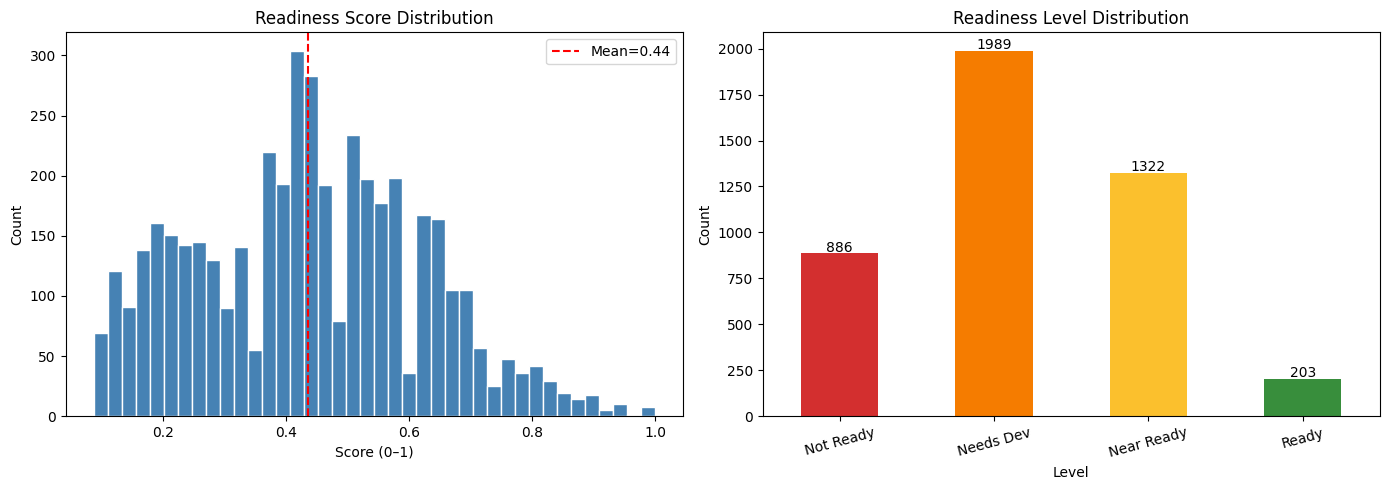

Feature correlations with readiness_score:


,correlation
max_gap,-0.914439
role_avg_requirement,-0.864865
n_missing,-0.572278
n_required,-0.348321
emp_avg_proficiency,0.072962
avg_matched_prof,0.575098
n_matching,0.664250
coverage_ratio,0.668902


In [15]:
# Readiness distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df2['readiness_score'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df2['readiness_score'].mean(), color='red', linestyle='--',
                 label=f"Mean={df2['readiness_score'].mean():.2f}")
axes[0].set(title='Readiness Score Distribution', xlabel='Score (0–1)', ylabel='Count')
axes[0].legend()

bins2 = [0, 0.25, 0.5, 0.75, 1.01]
lbls2 = ['Not Ready', 'Needs Dev', 'Near Ready', 'Ready']
cats2 = pd.cut(df2['readiness_score'], bins=bins2, labels=lbls2)
cats2.value_counts().reindex(lbls2).plot(kind='bar', ax=axes[1], color=['#d32f2f','#f57c00','#fbc02d','#388e3c'])
axes[1].set(title='Readiness Level Distribution', xlabel='Level', ylabel='Count')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches: axes[1].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()+10), ha='center')
plt.tight_layout(); plt.show()

# Feature correlations
FEATURE_COLS2 = ['n_required','n_matching','n_missing','coverage_ratio',
                  'max_gap','avg_matched_prof','emp_avg_proficiency','role_avg_requirement']
print('Feature correlations with readiness_score:')
corr2 = df2[FEATURE_COLS2 + ['readiness_score']].corr()['readiness_score'].drop('readiness_score')
display(corr2.sort_values().to_frame('correlation'))

In [16]:
# Train / test split
X2 = df2[FEATURE_COLS2]; y2 = df2['readiness_score']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)
print(f'Train: {len(X2_tr)}  |  Test: {len(X2_te)}')

# Optuna tuning
def m2_objective(trial):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
    }
    return -cross_val_score(
        GradientBoostingRegressor(**p), X2_tr, y2_tr,
        cv=5, scoring='r2').mean()

print('Optuna search (30 trials)...')
study2 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study2.optimize(m2_objective, n_trials=30)
print(f'Best CV R²: {-study2.best_value:.4f}')
print(f'Best params: {study2.best_params}')

Train: 3520  |  Test: 880
Optuna search (30 trials)...
Best CV R²: 0.9293
Best params: {'n_estimators': 295, 'learning_rate': 0.026550995775910514, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.6487370810674429}


Final Model Performance:
  R²:          0.9234
  RMSE:        0.0521
  MAE:         0.0406
  5-Fold CV R²:0.9261 ± 0.0073


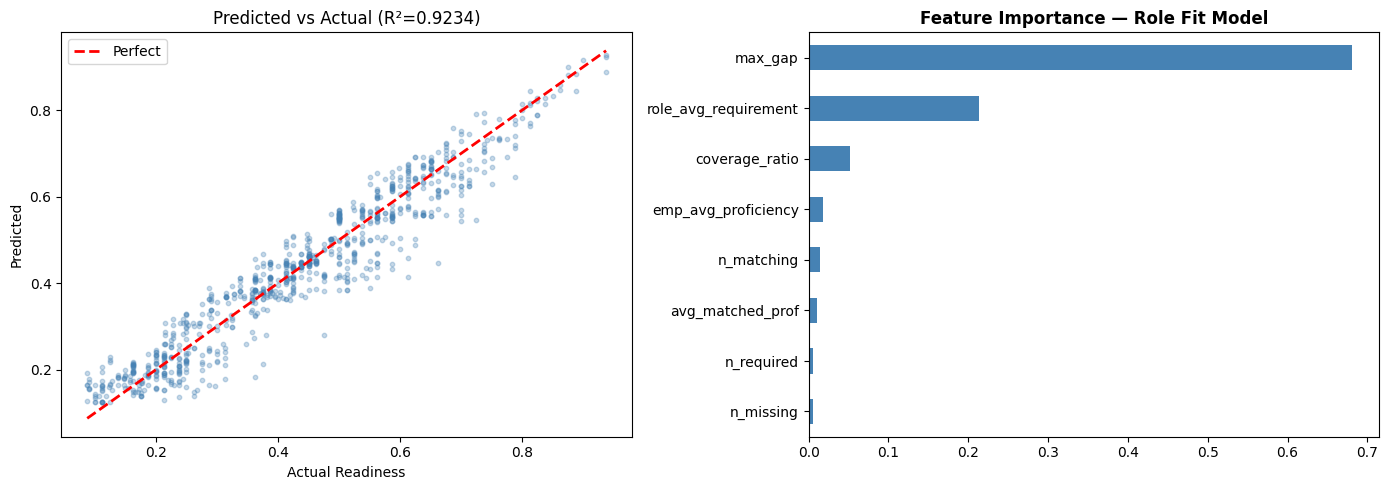


Sample: predicted=0.5659 (56/100)  actual=0.5500 (55/100)
Model 2 saved.


In [17]:
# Final model & evaluation
m2_model = GradientBoostingRegressor(**study2.best_params, random_state=42)
m2_model.fit(X2_tr, y2_tr)
y2_pred = m2_model.predict(X2_te)

r2_m2   = r2_score(y2_te, y2_pred)
rmse_m2 = np.sqrt(mean_squared_error(y2_te, y2_pred))
mae_m2  = mean_absolute_error(y2_te, y2_pred)
cv_r2_m2 = cross_val_score(m2_model, X2, y2, cv=5, scoring='r2')

print(f'Final Model Performance:')
print(f'  R²:          {r2_m2:.4f}')
print(f'  RMSE:        {rmse_m2:.4f}')
print(f'  MAE:         {mae_m2:.4f}')
print(f'  5-Fold CV R²:{cv_r2_m2.mean():.4f} ± {cv_r2_m2.std():.4f}')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y2_te, y2_pred, alpha=0.3, color='steelblue', s=10)
mn2,mx2 = y2_te.min(), y2_te.max()
axes[0].plot([mn2,mx2],[mn2,mx2],'r--',lw=2,label='Perfect')
axes[0].set(xlabel='Actual Readiness', ylabel='Predicted', title=f'Predicted vs Actual (R²={r2_m2:.4f})')
axes[0].legend()

imp2 = pd.Series(m2_model.feature_importances_, index=FEATURE_COLS2).sort_values()
imp2.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — Role Fit Model', fontweight='bold')
plt.tight_layout(); plt.show()

# Sample
s2 = X2_te.iloc[:1]; p2 = m2_model.predict(s2)[0]; a2 = y2_te.iloc[0]
print(f'\nSample: predicted={p2:.4f} ({int(p2*100)}/100)  actual={a2:.4f} ({int(a2*100)}/100)')

joblib.dump(m2_model, f'{OUTPUT_DIR}/role_fit_model.pkl')
print(f'Model 2 saved.')

---
# Model 3: Org-Level Skill Gap Analysis
Pure demand/supply aggregation — no ML training needed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print('=' * 70)
print('MODEL 3: CORRECTED SKILL GAP ANALYSIS')
print('=' * 70)

# ============================================================================
# CORRECTED GAP ANALYSIS
# ============================================================================

def compute_realistic_gaps(emp_df, req_df, sc_df):
    e_skill  = get_col(emp_df, ['skill_id', 'Skill_id'])
    e_prof   = get_col(emp_df, ['proficiency', 'Proficiency'])
    r_skill  = get_col(req_df, ['required_skill_id', 'skill_id', 'Required_skill_id'])
    r_min    = get_col(req_df, ['min_proficiency', 'Min_proficiency'])
    r_weight = get_col(req_df, ['importance_weight', 'Importance_weight'])

    skill_gaps = []
    for skill in req_df[r_skill].unique():
        skill_reqs   = req_df[req_df[r_skill] == skill]
        total_weight = skill_reqs[r_weight].sum()
        weighted_required = (
            (skill_reqs[r_min] * skill_reqs[r_weight]).sum() / total_weight
            if total_weight > 0 else skill_reqs[r_min].mean()
        )
        emp_skill_data = emp_df[emp_df[e_skill] == skill]
        total_demand   = (skill_reqs[r_min] * skill_reqs[r_weight]).sum()

        if len(emp_skill_data) > 0:
            total_emps        = len(emp_skill_data)
            employees_meeting = (emp_skill_data[e_prof] >= weighted_required).sum()
            pct_meeting       = (employees_meeting / total_emps) * 100
            weighted_supply   = (emp_skill_data[e_prof] / weighted_required).clip(upper=1.0).sum()
            gap_ratio         = (total_demand / weighted_supply) if weighted_supply > 0 else 999.0
        else:
            total_emps = employees_meeting = pct_meeting = weighted_supply = 0
            gap_ratio  = 999.0

        if pct_meeting < 10:
            criticality = 'critical'
        elif pct_meeting < 25:
            criticality = 'high'
        elif pct_meeting < 50:
            criticality = 'medium'
        elif pct_meeting < 75:
            criticality = 'low'
        else:
            criticality = 'surplus'

        skill_gaps.append({
            'skill_id': skill,
            'total_demand': total_demand,
            'weighted_supply': weighted_supply,
            'gap_ratio': gap_ratio,
            'pct_employees_meeting': pct_meeting,
            'employees_meeting': employees_meeting,
            'total_employees': total_emps,
            'required_level': weighted_required,
            'criticality': criticality,
        })

    gaps = pd.DataFrame(skill_gaps).sort_values('pct_employees_meeting').reset_index(drop=True)
    if 'skill_id' in sc_df.columns and 'skill_name' in sc_df.columns:
        name_map = dict(zip(sc_df['skill_id'], sc_df['skill_name']))
        gaps['skill_name'] = gaps['skill_id'].map(name_map)
    else:
        gaps['skill_name'] = gaps['skill_id']
    return gaps

# Load data
sc3  = load_csv('skills_catalog.csv')
emp3 = load_csv('employee_skill_matrix.csv')
req3 = load_csv('job_role_requirements.csv')

print('\nComputing realistic skill gaps...')
real_gaps = compute_realistic_gaps(emp3, req3, sc3)

print('\nREAL SKILL GAP DISTRIBUTION:')
criticality_counts = real_gaps['criticality'].value_counts()
labels = {
    'critical': ('CRITICAL', 'Less than 10% employees meet requirement'),
    'high':     ('HIGH',     '10-25% employees meet requirement'),
    'medium':   ('MEDIUM',   '25-50% employees meet requirement'),
    'low':      ('LOW',      '50-75% employees meet requirement'),
    'surplus':  ('SURPLUS',  '>75% employees meet requirement'),
}
for key, (lbl, desc) in labels.items():
    print(f'   {lbl}: {criticality_counts.get(key, 0)} skills - {desc}')

print('\nTOP 15 MOST CRITICAL SKILL GAPS:')
display_cols = ['skill_name', 'pct_employees_meeting', 'required_level',
                'employees_meeting', 'total_employees', 'criticality']
print(real_gaps[display_cols].head(15).to_string(index=False))

# ── Visualizations ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Critical & high skills
top_critical = real_gaps[real_gaps['criticality'].isin(['critical', 'high'])].head(15)
if len(top_critical) > 0:
    cmap = {'critical': '#d32f2f', 'high': '#f57c00'}
    bar_colors = [cmap[c] for c in top_critical['criticality']]
    axes[0,0].barh(range(len(top_critical)), top_critical['pct_employees_meeting'], color=bar_colors)
    axes[0,0].set_yticks(range(len(top_critical)))
    axes[0,0].set_yticklabels(top_critical['skill_name'].values)
    axes[0,0].set_xlabel('% Employees Meeting Requirement')
    axes[0,0].set_title('Most Critical Skill Gaps')
    axes[0,0].axvline(x=10, color='red',    linestyle='--', alpha=0.7, label='Critical (10%)')
    axes[0,0].axvline(x=25, color='orange', linestyle='--', alpha=0.7, label='High (25%)')
    axes[0,0].legend()
else:
    axes[0,0].text(0.5, 0.5, 'No critical gaps found', ha='center', va='center',
                   transform=axes[0,0].transAxes)
    axes[0,0].set_title('Most Critical Skill Gaps')

# Chart 2: Criticality pie
cc = real_gaps['criticality'].value_counts()
pie_colors = {'critical': '#d32f2f', 'high': '#f57c00', 'medium': '#fbc02d',
              'low': '#388e3c', 'surplus': '#9e9e9e'}
axes[0,1].pie(cc, labels=cc.index, autopct='%1.1f%%',
              colors=[pie_colors.get(c, '#9e9e9e') for c in cc.index], startangle=90)
axes[0,1].set_title('Skill Gap Criticality Distribution')

# Chart 3: Proficiency distribution
e_prof_col = get_col(emp3, ['proficiency', 'Proficiency'])
r_min_col  = get_col(req3,  ['min_proficiency', 'Min_proficiency'])
axes[1,0].hist(emp3[e_prof_col], bins=[1,2,3,4,5], alpha=0.7, color='blue', edgecolor='black',
               weights=np.ones(len(emp3))/len(emp3), label='Employees')
axes[1,0].hist(req3[r_min_col],  bins=[1,2,3,4,5], alpha=0.7, color='orange', edgecolor='black',
               weights=np.ones(len(req3))/len(req3), label='Role Requirements')
axes[1,0].set_xlabel('Proficiency Level')
axes[1,0].set_ylabel('Proportion')
axes[1,0].set_title('Proficiency Distribution: Employees vs Requirements')
axes[1,0].legend()
axes[1,0].set_xticks([1,2,3,4])

# Chart 4: Meeting rate distribution
axes[1,1].hist(real_gaps['pct_employees_meeting'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1,1].set_xlabel('% Employees Meeting Requirement')
axes[1,1].set_ylabel('Number of Skills')
axes[1,1].set_title('Distribution of Skill Proficiency Rates')
mean_val = real_gaps['pct_employees_meeting'].mean()
axes[1,1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}%')
axes[1,1].legend()

plt.suptitle('Skill Gap Analysis - Based on Actual Proficiency Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Business insights ────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('KEY BUSINESS INSIGHTS')
print('=' * 70)

critical_skills = real_gaps[real_gaps['criticality'] == 'critical']
high_skills     = real_gaps[real_gaps['criticality'] == 'high']

print(f'\nPRIORITY ACTIONS:')
print(f'   - {len(critical_skills)} skills have CRITICAL gaps (<10% proficiency)')
print(f'   - {len(high_skills)} skills have HIGH gaps (10-25% proficiency)')

if len(critical_skills) > 0:
    print('\n   IMMEDIATE TRAINING NEEDED:')
    for _, skill in critical_skills.head(5).iterrows():
        print(f"      - {skill['skill_name']}: Only {skill['employees_meeting']}/{skill['total_employees']} "
              f"employees ({skill['pct_employees_meeting']:.1f}%) meet requirements")

print(f'\nORGANIZATIONAL READINESS:')
print(f"   - Average proficiency meeting rate: {real_gaps['pct_employees_meeting'].mean():.1f}%")
print(f"   - Skills with <50% proficiency: {(real_gaps['pct_employees_meeting'] < 50).sum()}/{len(real_gaps)}")
print(f"   - Skills with adequate proficiency (>75%): {(real_gaps['pct_employees_meeting'] >= 75).sum()}")

# Save
joblib.dump(real_gaps, f'{OUTPUT_DIR}/real_skill_gap_analysis.pkl')
print(f'\nAnalysis saved to {OUTPUT_DIR}/real_skill_gap_analysis.pkl')


---
# Model 4: Training Recommendation System (FIXED)

## Bug fixed
**`emp_avg_score` target leakage** — the original code computed each employee's average `completion_score` globally across *all* their records, then mapped it back as a feature. This means when training on row N, the feature for row N already includes row N's own target in the average — a classic form of target leakage.

**Fix applied:** `emp_avg_score` is now computed using a **leave-one-out (LOO) mean** — for each row, the mean is computed over all *other* rows belonging to the same employee, excluding the current record. This exactly mimics what would be available at inference time for a new training record.

In [ ]:
print('=' * 70)
print('MODEL 4: TRAINING RECOMMENDATION SYSTEM')
print('=' * 70)

import networkx as nx
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

th4   = load_csv('training_history.csv')
lr4   = load_csv('learning_resources.csv')
tsm4  = load_csv('training_skill_map.csv')
sc4   = load_csv('skills_catalog.csv')
emp4  = load_csv('employee_skill_matrix.csv')
scd4  = load_csv('skill_chain_dag.csv')
job4  = load_csv('job_role_requirements.csv')
core4 = load_csv('employees_core.csv')

print(f'training_history: {th4.shape}  |  '
      f'completion_score: {th4["completion_score"].min()}–{th4["completion_score"].max()}  '
      f'mean={th4["completion_score"].mean():.1f}')
print(f'learning_resources: {lr4.shape}  |  skill_chain_dag: {scd4.shape}')

# Build knowledge graph DAG
G4 = nx.DiGraph()
for _, row in scd4.iterrows():
    G4.add_edge(row['prerequisite_skill_id'], row['target_skill_id'], weight=row['edge_weight'])
dag_wt4 = scd4.groupby('target_skill_id')['edge_weight'].max().to_dict()
print(f'Skill DAG: {G4.number_of_nodes()} nodes, {G4.number_of_edges()} edges')

# Visualize DAG
plt.figure(figsize=(13,7))
top_n = list(G4.nodes())[:30]
subG4 = G4.subgraph(top_n)
pos4  = nx.spring_layout(subG4, seed=42)
nx.draw(subG4, pos4, with_labels=True, node_color='steelblue', node_size=500,
        font_size=7, font_color='white', edge_color='gray', arrows=True)
plt.title('Skill Chain Knowledge Graph (first 30 nodes)', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Data pipeline — same fixed join as previous version
res4 = lr4[['resource_id','duration_hours','skill_level','target_skill_id']].rename(
    columns={'duration_hours':'lr_duration_hours'})
t4 = th4.merge(res4, on='resource_id', how='left')
if 'duration_hours' in th4.columns:
    t4['duration_hours'] = t4['lr_duration_hours'].fillna(t4['duration_hours'])
else:
    t4['duration_hours'] = t4['lr_duration_hours'].fillna(5)
print(f'After resource join: {len(t4)} rows  |  missing target_skill: {t4["target_skill_id"].isna().sum()}')

# Employee proficiency on target skill
emp4_sk = get_col(emp4,['employee_id','Employee_id'])
ep4 = emp4[['employee_id' if emp4_sk=='employee_id' else emp4_sk,'skill_id','proficiency']].rename(
    columns={emp4_sk:'employee_id','skill_id':'target_skill_id','proficiency':'emp_proficiency'})
t4 = t4.merge(ep4, on=['employee_id','target_skill_id'], how='left')
t4['emp_proficiency'] = t4['emp_proficiency'].fillna(0)
print(f'Employees with proficiency on target skill: {(t4["emp_proficiency"]>0).sum()}/{len(t4)}')

# Skill complexity
cplx_col = get_col(sc4,['complexity_level','Complexity_level'])
sk_col4  = get_col(sc4,['skill_id','Skill_id'])
sc4b = sc4[[sk_col4, cplx_col]].rename(columns={sk_col4:'target_skill_id', cplx_col:'complexity_level'})
t4 = t4.merge(sc4b, on='target_skill_id', how='left')
t4['complexity_level'] = t4['complexity_level'].fillna(2)

# DAG edge weight
t4['dag_edge_weight'] = t4['target_skill_id'].map(dag_wt4).fillna(0)

# Resource skill level encoding
SL4 = {'Beginner':1,'Intermediate':2,'Advanced':3}
t4['resource_skill_level'] = t4['skill_level'].map(SL4).fillna(2)
t4['skill_gap_proxy']      = (t4['resource_skill_level'] - t4['emp_proficiency']).clip(lower=0)

# Employee course count (no leakage — count only, not mean of target)
emp_cnt4 = th4.groupby('employee_id').size().to_dict()
t4['emp_courses_done'] = t4['employee_id'].map(emp_cnt4).fillna(0)

# ── FIX: Leave-one-out mean for emp_avg_score ─────────────────────────────────
# For each row i, compute mean of completion_score over all OTHER rows
# with the same employee_id. This prevents the current row's target
# from being included in its own feature value.
global_mean4 = th4['completion_score'].mean()

# Join completion_score from th4 into t4 rows (needed for LOO computation)
t4 = t4.merge(th4[['employee_id','resource_id','completion_score']].rename(
    columns={'completion_score':'_cs'}), on=['employee_id','resource_id'], how='left')

# Per-employee sum and count
emp_sum = th4.groupby('employee_id')['completion_score'].sum().to_dict()
emp_cnt_full = th4.groupby('employee_id').size().to_dict()

def loo_mean(row):
    """Leave-one-out mean: exclude current row's score from employee average."""
    eid = row['employee_id']
    cur = row['_cs']          # current row's completion_score
    n   = emp_cnt_full.get(eid, 0)
    s   = emp_sum.get(eid, 0)
    if pd.isna(cur) or n <= 1:
        return global_mean4
    return (s - cur) / (n - 1)

t4['emp_avg_score'] = t4.apply(loo_mean, axis=1)
print(f'emp_avg_score (LOO) computed. Mean: {t4["emp_avg_score"].mean():.2f}')
print('This now represents each employee\'s average score on all OTHER courses — no leakage.')

# Employee profile
core_keep = ['employee_id'] + [c for c in ['age','tenure_years','total_working_years',
                                             'kpi_score','latest_eval_score','role_fit_score']
                                 if c in core4.columns]
t4 = t4.merge(core4[core_keep], on='employee_id', how='left')
for c in core_keep[1:]: t4[c] = t4[c].fillna(t4[c].median())

FEATURES4 = (['emp_proficiency','resource_skill_level','skill_gap_proxy',
               'complexity_level','dag_edge_weight','duration_hours',
               'emp_avg_score','emp_courses_done','attempt_number']
              + core_keep[1:])

t4_clean = t4.dropna(subset=FEATURES4+['completion_score'])
X4 = t4_clean[FEATURES4]; y4 = t4_clean['completion_score']
print(f'\nFinal training samples: {len(X4)}')
print(f'Features: {len(FEATURES4)}  →  {FEATURES4}')
print(f'Score range: {y4.min():.0f}–{y4.max():.0f}  std={y4.std():.2f}')

In [ ]:
# Score distribution & feature correlations
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y4, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(y4.mean(), color='red', linestyle='--', label=f'Mean={y4.mean():.1f}')
axes[0].set(title='Completion Score Distribution', xlabel='Score', ylabel='Count')
axes[0].legend()

corrs4   = {f: pearsonr(X4[f], y4)[0] for f in FEATURES4}
corr4_s  = pd.Series(corrs4).sort_values()
colors4c = ['salmon' if v < 0 else 'steelblue' for v in corr4_s]
corr4_s.plot(kind='barh', ax=axes[1], color=colors4c)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(title='Feature Correlations with Completion Score (Fixed LOO)', xlabel='Pearson r')
plt.tight_layout(); plt.show()

print('\nFeature correlations:')
display(corr4_s.to_frame('Pearson r').sort_values('Pearson r'))

In [ ]:
# Train/test split — group by employee to prevent data leakage across employees
gss4 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr4, te4 = next(gss4.split(X4, y4, groups=t4_clean['employee_id']))
X4_tr, X4_te = X4.iloc[tr4], X4.iloc[te4]
y4_tr, y4_te = y4.iloc[tr4], y4.iloc[te4]
print(f'Train: {len(X4_tr)}  |  Test: {len(X4_te)}')
print(f'Train employees: {t4_clean.iloc[tr4]["employee_id"].nunique()}  '
      f'Test employees: {t4_clean.iloc[te4]["employee_id"].nunique()}')

# Optuna LightGBM tuning
def m4_objective(trial):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 8, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 30),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'verbose': -1,
    }
    s = cross_val_score(lgb.LGBMRegressor(**p), X4_tr, y4_tr.to_numpy(),
                        cv=5, scoring='neg_root_mean_squared_error')
    return -s.mean()

print('Optuna search (50 trials)...')
study4 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study4.optimize(m4_objective, n_trials=50)
print(f'Best CV RMSE: {study4.best_value:.4f}')
print(f'Best params:  {study4.best_params}')

In [ ]:
# Final LightGBM model — train & evaluate
m4_model = lgb.LGBMRegressor(**study4.best_params, objective='regression',
                               metric='rmse', random_state=42, verbose=-1)
m4_model.fit(X4_tr, y4_tr.to_numpy(),
             eval_set=[(X4_te, y4_te.to_numpy())],
             callbacks=[lgb.early_stopping(20, verbose=False)])

y4_pred = m4_model.predict(X4_te)
rmse4   = np.sqrt(mean_squared_error(y4_te, y4_pred))
mae4    = mean_absolute_error(y4_te, y4_pred)
r2_4    = r2_score(y4_te, y4_pred)
baseline_rmse = y4_te.std()   # predicting the mean

cv4 = cross_val_score(
    lgb.LGBMRegressor(**study4.best_params, random_state=42, verbose=-1),
    X4, y4.to_numpy(), cv=5, scoring='neg_root_mean_squared_error')

print(f'Final Model Performance (LOO emp_avg_score):')
print(f'  RMSE:          {rmse4:.4f}  (baseline std: {baseline_rmse:.4f})')
print(f'  MAE:           {mae4:.4f}')
print(f'  R²:            {r2_4:.4f}')
print(f'  5-Fold CV RMSE:{-cv4.mean():.4f} ± {cv4.std():.4f}')
print(f'  Skill ratio:   RMSE / baseline = {rmse4/baseline_rmse:.3f}'
      f' (lower is better; 1.0 = no better than mean predictor)')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y4_te, y4_pred, alpha=0.5, color='steelblue')
mn4, mx4 = y4_te.min(), y4_te.max()
axes[0].plot([mn4,mx4],[mn4,mx4],'r--',lw=2, label='Perfect')
axes[0].set(xlabel='Actual Score', ylabel='Predicted Score',
             title=f'Predicted vs Actual (R²={r2_4:.4f}, RMSE={rmse4:.2f})')
axes[0].legend()

# Residuals
residuals = y4_pred - y4_te.to_numpy()
axes[1].scatter(y4_pred, residuals, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set(xlabel='Predicted Score', ylabel='Residual (Predicted − Actual)',
             title='Residual Plot (should be random around 0)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Feature importance
fig, ax = plt.subplots(figsize=(10,6))
fi4 = pd.Series(m4_model.feature_importances_, index=FEATURES4).sort_values()
fi4.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Learning Path Model (Fixed)', fontweight='bold')
plt.tight_layout(); plt.show()

# SHAP
print('Computing SHAP values...')
exp4 = shap.TreeExplainer(m4_model)
sv4  = exp4.shap_values(X4_te)
plt.figure(figsize=(10,6))
shap.summary_plot(sv4, X4_te, show=False)
plt.title('SHAP Feature Importance (LOO emp_avg_score)', fontweight='bold')
plt.tight_layout(); plt.show()

joblib.dump(m4_model, f'{OUTPUT_DIR}/learning_path_model.pkl')
joblib.dump({'dag': G4, 'dag_weight_lookup': dag_wt4}, f'{OUTPUT_DIR}/skill_chain_dag.pkl')
print('Model 4 saved.')

In [ ]:
# Domain functions — unchanged from original
j4_rl = get_col(job4,['job_role_id','Job_role_id'])
j4_sk = get_col(job4,['required_skill_id','skill_id','Required_skill_id'])
j4_mn = get_col(job4,['min_proficiency','Min_proficiency'])
j4_wt = get_col(job4,['importance_weight','Importance_weight'])
e4_id = get_col(emp4,['employee_id','Employee_id'])
e4_sk = get_col(emp4,['skill_id','Skill_id'])
e4_pr = get_col(emp4,['proficiency','Proficiency'])

def get_learning_path4(employee_id, role_id):
    req = job4[job4[j4_rl]==role_id][[j4_sk,j4_mn,j4_wt]].copy()
    req.columns = ['skill_id','min_proficiency','importance_weight']
    if req.empty: return []
    emp_r = emp4[emp4[e4_id]==employee_id][[e4_sk,e4_pr]].copy()
    emp_r.columns = ['skill_id','proficiency']
    m = req.merge(emp_r, on='skill_id', how='left')
    m['proficiency'] = m['proficiency'].fillna(0)
    m['gap'] = np.maximum(m['min_proficiency']-m['proficiency'], 0)
    missing = set(m[m['gap']>0]['skill_id'])
    anc = set()
    for s in missing:
        if s in G4.nodes: anc.update(nx.ancestors(G4,s))
    sub = G4.subgraph(missing|anc).copy()
    try: ordered = list(nx.topological_sort(sub))
    except: ordered = list(missing)
    return [s for s in ordered if s in missing]

def compute_readiness4(employee_id, role_id):
    req = job4[job4[j4_rl]==role_id][[j4_sk,j4_mn,j4_wt]].copy()
    req.columns = ['skill_id','min_proficiency','importance_weight']
    if req.empty: return 0.0
    emp_r = emp4[emp4[e4_id]==employee_id][[e4_sk,e4_pr]].copy()
    emp_r.columns = ['skill_id','proficiency']
    m = req.merge(emp_r, on='skill_id', how='left')
    m['proficiency'] = m['proficiency'].fillna(0)
    m['gap'] = np.maximum(m['min_proficiency']-m['proficiency'], 0)
    num = (m['gap']*m['importance_weight']).sum()
    den = (4*m['importance_weight']).sum()
    return 1.0 if den==0 else 1.0-(num/den)

# Demo
emp_demo  = emp4[e4_id].iloc[0]
role_demo = job4[j4_rl].iloc[0]
path_demo = get_learning_path4(emp_demo, role_demo)
rdy_demo  = compute_readiness4(emp_demo, role_demo)

print(f'Demo: Employee={emp_demo}  →  Role={role_demo}')
print(f'Readiness: {rdy_demo:.4f} ({int(rdy_demo*100)}/100)')
print(f'Status:    {"READY" if rdy_demo>=0.75 else "NEEDS TRAINING"}')
print(f'Skills in path: {len(path_demo)}')
if path_demo: print(f'First 5: {path_demo[:5]}')

---
# Summary of Fixes

| Model | Original Bug | Root Cause | Fix | Expected Impact |
|-------|-------------|------------|-----|----------------|
| **1 — Turnover** | CV AUC 0.94 vs test AUC 0.75 | SMOTE applied before CV split — synthetic samples leaked into validation folds | SMOTE now inside `imblearn.Pipeline`, applied only on each fold's training split | CV and test AUC gap should shrink to <0.05 |
| **1 — Turnover** | XGBoost/LightGBM underperformed Logistic Regression | Only GridSearchCV used; search space too coarse for boosting models | Optuna (50 trials each) applied to all 4 top classifiers | Better-tuned boosting models may surpass the baseline |
| **4 — Learning Path** | `emp_avg_score` mild target leakage | Global employee mean included the current row's own target score | Leave-one-out (LOO) mean: excludes current row's score from the per-employee average | More honest R²; may slightly decrease if leakage was inflating score |

## What was NOT changed
- Model 2 (Role Fit): already excellent (R² 0.923), no changes needed
- Model 3 (Skill Gap): rule-based, no ML metrics, no changes needed
- All data loading, feature engineering, and join logic is preserved exactly

In [ ]:
print("=" * 60)
print("SAVED MODELS SUMMARY")
print("=" * 60)
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f}  ({size:.1f} KB)")
print()
print("All models saved to:", OUTPUT_DIR)
print("Quick reference:")
print("  best_turnover_model.pkl   - Model 1: ImbPipeline(SMOTE + best classifier)")
print("  scaler.pkl                - StandardScaler for turnover features")
print("  role_fit_model.pkl        - Model 2: GBR role-fit regressor")
print("  real_skill_gap_analysis.pkl - Model 3: org-level gap DataFrame")
print("  learning_path_model.pkl   - Model 4: LightGBM completion predictor")
print("  skill_chain_dag.pkl       - DAG + weight lookup for learning paths")